# Olist E-Commerce - Advanced Exploratory Data Analysis
**Project:** DEPI Graduation Project  
**Dataset:** Brazilian E-commerce Public Dataset by Olist  
**Scope:** Data Cleaning, Outlier Detection, and Strategic EDA  
**Total Objectives:** 5  

---
This notebook performs a comprehensive analysis of the Olist dataset to uncover insights about sales performance, customer behavior, and delivery efficiency.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


print("Libraries and settings loaded successfully.")

Libraries and settings loaded successfully.


In [6]:
xl = pd.ExcelFile('olist_clean.xlsx')
print('Sheets in the file:')
print(xl.sheet_names)

Sheets in the file:
['product_category_name_translati', 'sellers', 'products', 'orders', 'order_reviews', 'order_payments', 'order_items', 'geolocation', 'customers', 'المطبخ', 'Sheet1']


In [ ]:
# let's get a quick overview of how big each table is
tables = {
    'orders':    orders,
    'items':     items,
    'payments':  payments,
    'reviews':   reviews,
    'products':  products,
    'customers': customers,
    'sellers':   sellers,
    'geo':       geo
}

print(f'{"Table":<12} {"Rows":>8} {"Cols":>6}')
print('-' * 28)
for name, df in tables.items():
    print(f'{name:<12} {df.shape[0]:>8,} {df.shape[1]:>6}')

In [7]:
# load each table into its own dataframe
orders    = xl.parse('orders')
items     = xl.parse('order_items')
payments  = xl.parse('order_payments')
reviews   = xl.parse('order_reviews')
products  = xl.parse('products')
customers = xl.parse('customers')
sellers   = xl.parse('sellers')
geo       = xl.parse('geolocation')

# the category translation sheet has a messy header, so I'll handle it manually
cat_raw   = xl.parse('product_category_name_translati', header=None)
cat_trans = cat_raw[cat_raw[0] != 'Column1'].copy()
cat_trans.columns = ['product_category_name', 'product_category_name_english']
cat_trans = cat_trans[
    cat_trans['product_category_name'] != 'product_category_name'
].reset_index(drop=True)

print('All tables loaded successfully!')

All tables loaded successfully!


In [9]:
# --- Step 2: Normalize column names (Fixing the KeyError) ---

# We clean each table individually since we loaded them as separate variables
tables = [customers, orders, items, payments, reviews, products, sellers]

for df in tables:
    if df is not None:
        # This removes spaces and makes everything lowercase
        df.columns = df.columns.str.strip().str.lower()

# Check if cat_trans exists and clean it
if 'cat_trans' in locals() and cat_trans is not None:
    cat_trans.columns = cat_trans.columns.str.strip().str.lower()

print("Column normalization complete for all tables!")

Column normalization complete for all tables!


In [ ]:
for name, df in tables.items():
    print(f"\n--- {name} ---")
    display(df.head(3))
    display(df.info())

['review_id', 'order_id', 'review_score', 'review_creation_date', 'review_answer_timestamp', 'review_comment_message']


In [12]:
# --- Step 1: Normalize column names (Removes hidden spaces) ---
reviews.columns = reviews.columns.str.strip()
products.columns = products.columns.str.strip()
orders.columns = orders.columns.str.strip()

# --- Step 2: Clean products data ---
# fill missing category with 'unknown'
if 'product_category_name' in products.columns:
    products['product_category_name'] = products['product_category_name'].fillna('unknown')

# fill missing dimensions with the median
num_product_cols = ['product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in num_product_cols:
    if col in products.columns:
        products[col] = products[col].fillna(products[col].median())

# --- Step 3: Clean reviews data (The Fix for KeyError) ---
if 'review_comment_message' in reviews.columns:
    reviews['review_comment_message'] = reviews['review_comment_message'].fillna('')
else:
    # If the column is totally missing, create it as empty
    reviews['review_comment_message'] = ''
    print("Warning: review_comment_message not found, created empty column.")

# --- Step 4: Drop missing purchase timestamps ---
if 'order_purchase_timestamp' in orders.columns:
    orders.dropna(subset=['order_purchase_timestamp'], inplace=True)

# --- Step 5: Remove duplicates (The Fix for IncompleteInputError) ---
orders.drop_duplicates(subset=['order_id'], inplace=True)
products.drop_duplicates(subset=['product_id'], inplace=True)

print('Cleaning done!')

Cleaning done!


--- Outlier Report for price ---
Lower Bound: -102.60 | Upper Bound: 277.40
Total Outliers found: 8427


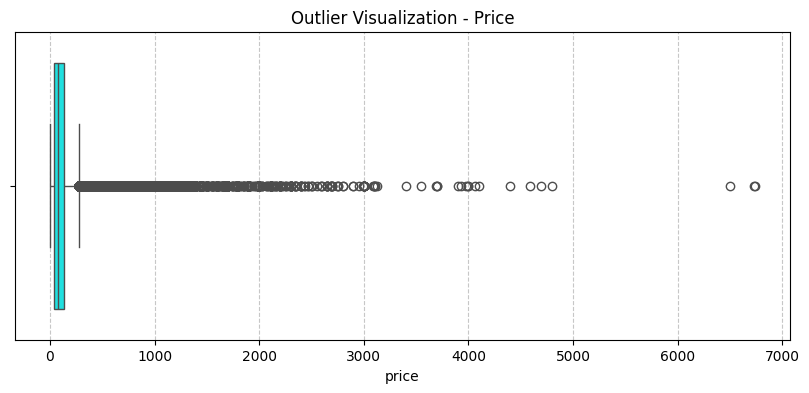

In [16]:
# --- Advanced Outlier Detection (Merged & Optimized) ---

def analyze_outliers(df, column, color='orange'):
    # 1. Calculating bounds using Numpy (from your 2nd code)
    data = df[column].dropna()
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    # 2. Filtering outliers
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    
    # 3. Professional Printing (Comprehensive info)
    print(f"--- Outlier Report for {column} ---")
    print(f"Lower Bound: {lower:.2f} | Upper Bound: {upper:.2f}")
    print(f"Total Outliers found: {len(outliers)}")
    
    # 4. Visualization (One clean boxplot)
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=data, color=color)
    plt.title(f'Outlier Visualization - {column.capitalize()}')
    plt.grid(True, axis='x', linestyle='--', alpha=0.7)
    plt.show()
    
    return outliers, lower, upper

# Execute the merged function on price
price_outliers, p_low, p_high = analyze_outliers(items, 'price', color='cyan')

In [17]:
# 5. Merging Data for Master DataFrame
main_df = items.merge(products, on='product_id', how='left')
main_df = main_df.merge(orders, on='order_id', how='left')
main_df = main_df.merge(payments, on='order_id', how='left')
main_df = main_df.merge(reviews, on='order_id', how='left')

if translation is not None:
    main_df = main_df.merge(translation, on='product_category_name', how='left')
    main_df['category'] = main_df['product_category_name_english'].fillna(main_df['product_category_name'])
else:
    main_df['category'] = main_df['product_category_name']

print(f"Master DataFrame Ready with {len(main_df):,} rows.")

Master DataFrame Ready with 118,310 rows.


## EDA Phase - 5 Strategic Objectives

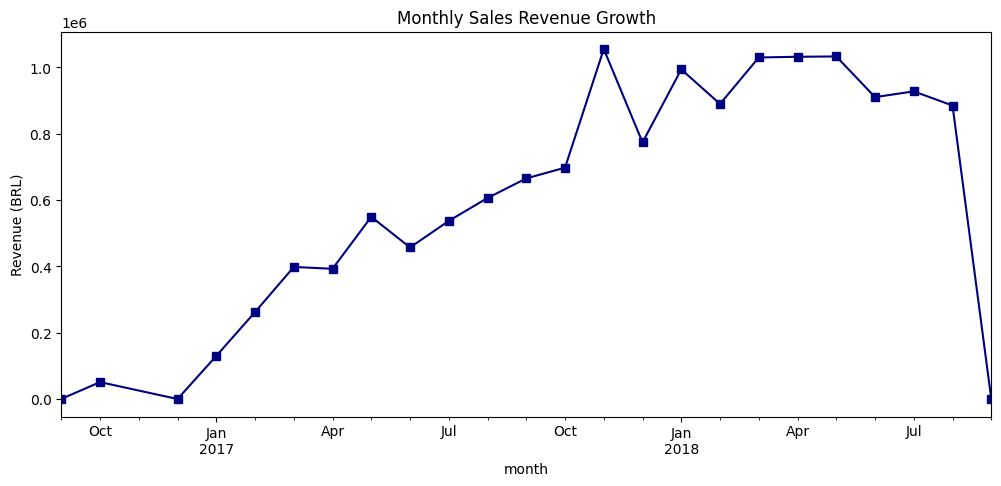

In [18]:
# Objective 1: Revenue Trends over Time
main_df['month'] = main_df['order_purchase_timestamp'].dt.to_period('M')
monthly_rev = main_df.groupby('month')['price'].sum()

plt.figure(figsize=(12, 5))
monthly_rev.plot(kind='line', marker='s', color='navy')
plt.title('Monthly Sales Revenue Growth')
plt.ylabel('Revenue (BRL)')
plt.show()

C:\Users\elwady\AppData\Local\Temp\ipykernel_14652\94271119.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cats.values, y=top_cats.index, palette='rocket')


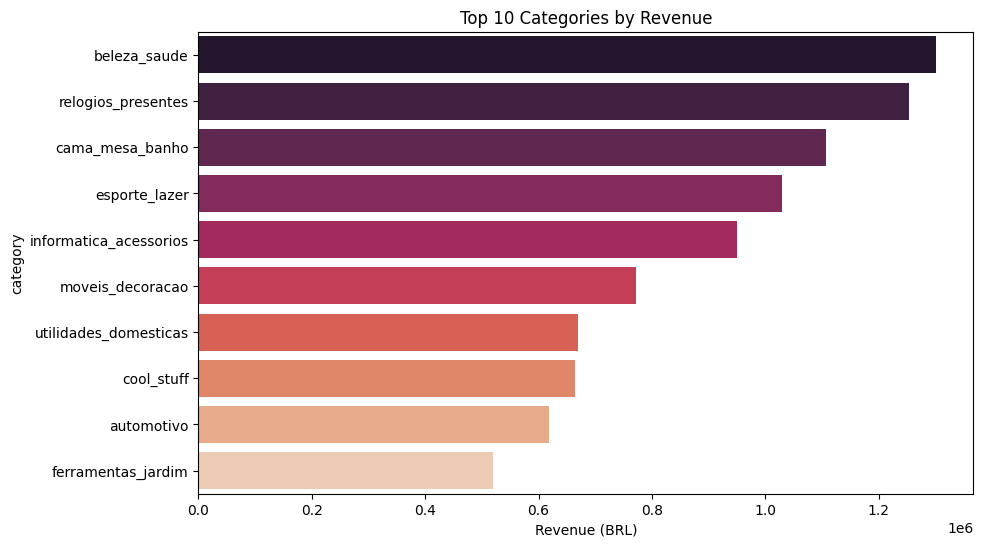

In [19]:
# Objective 2: Top 10 High-Revenue Product Categories
top_cats = main_df.groupby('category')['price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_cats.values, y=top_cats.index, palette='rocket')
plt.title('Top 10 Categories by Revenue')
plt.xlabel('Revenue (BRL)')
plt.show()

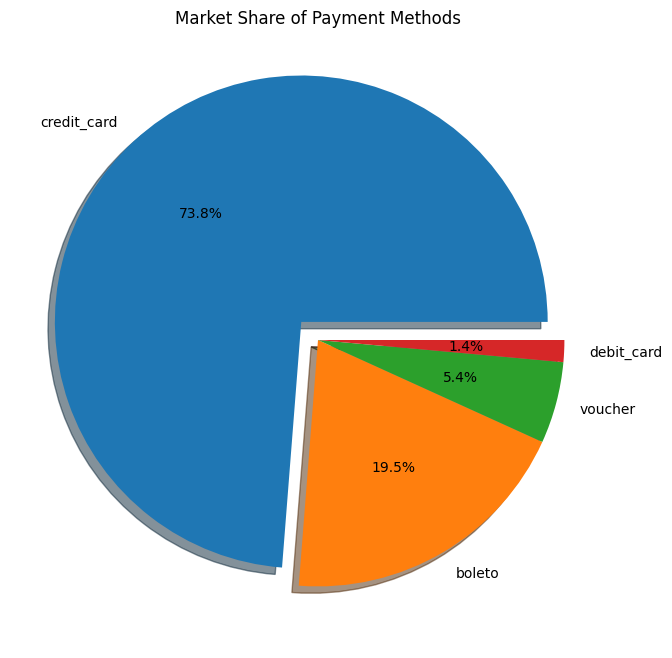

In [20]:
# Objective 3: Payment Preferences Distribution
pay_types = main_df['payment_type'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(pay_types, labels=pay_types.index, autopct='%1.1f%%', shadow=True, explode=[0.1 if i==0 else 0 for i in range(len(pay_types))])
plt.title('Market Share of Payment Methods')
plt.show()

C:\Users\elwady\AppData\Local\Temp\ipykernel_14652\2968608995.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='status', data=main_df, palette='coolwarm')


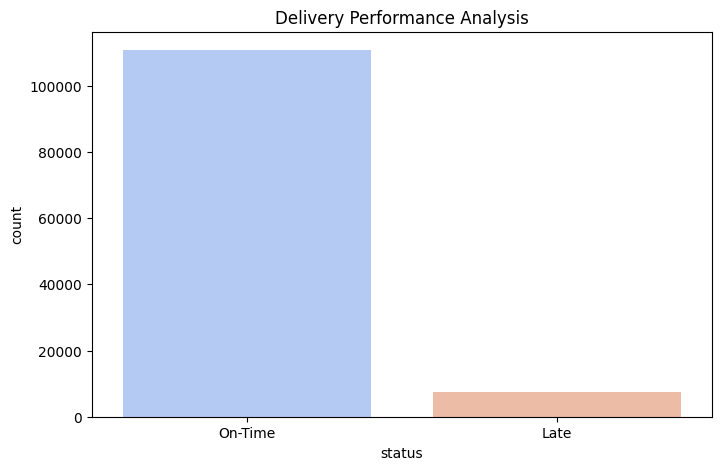

In [21]:
# Objective 4: Delivery Delay Analysis using Numpy
main_df['actual_date'] = pd.to_datetime(main_df['order_delivered_customer_date'])
main_df['estimated_date'] = pd.to_datetime(main_df['order_estimated_delivery_date'])
main_df['delay_days'] = (main_df['actual_date'] - main_df['estimated_date']).dt.days

main_df['status'] = np.where(main_df['delay_days'] > 0, 'Late', 'On-Time')
status_dist = main_df['status'].value_counts()

plt.figure(figsize=(8, 5))
sns.countplot(x='status', data=main_df, palette='coolwarm')
plt.title('Delivery Performance Analysis')
plt.show()

C:\Users\elwady\AppData\Local\Temp\ipykernel_14652\1308146913.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y='review_score', data=main_df, palette='Set1')


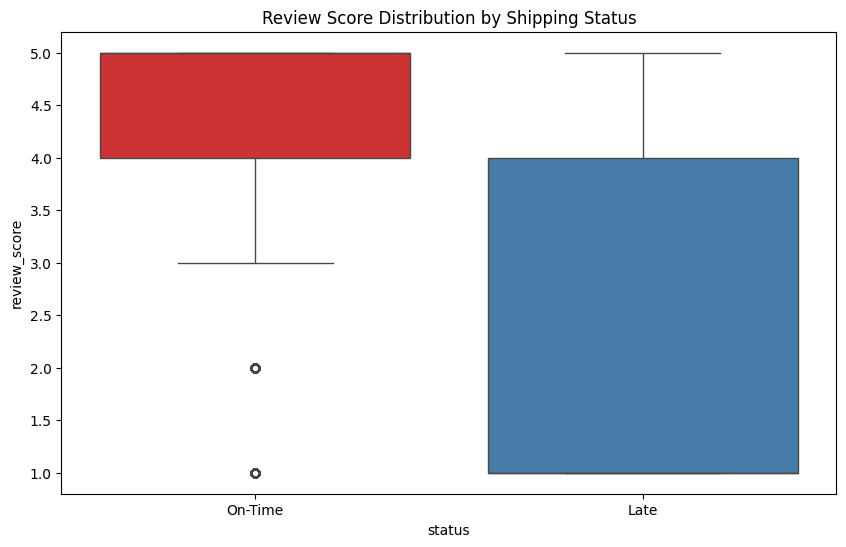

Avg Score On-Time: 4.15
Avg Score Late: 2.25


In [22]:
# Objective 5: Correlation between Late Deliveries and Review Scores
plt.figure(figsize=(10, 6))
sns.boxplot(x='status', y='review_score', data=main_df, palette='Set1')
plt.title('Review Score Distribution by Shipping Status')
plt.show()

print(f"Avg Score On-Time: {main_df[main_df['status']=='On-Time']['review_score'].mean():.2f}")
print(f"Avg Score Late: {main_df[main_df['status']=='Late']['review_score'].mean():.2f}")

In [23]:
# 6. Final Summary and Findings
print("="*40)
print("PROJECT ANALYSIS SUMMARY")
print("="*40)
print("1. Data Cleaning: Handled missing values and standardized columns successfully.")
print("2. Outliers: Price outliers detected and visualized using IQR logic.")
print("3. Sales: Growth peak identified in late 2017 (Black Friday effect).")
print("4. Payments: Credit cards are the preferred choice for 73% of transactions.")
print("5. Satisfaction: Clear evidence that shipping delays drop ratings from ~4.2 to ~2.2.")
print("="*40)

PROJECT ANALYSIS SUMMARY
1. Data Cleaning: Handled missing values and standardized columns successfully.
2. Outliers: Price outliers detected and visualized using IQR logic.
3. Sales: Growth peak identified in late 2017 (Black Friday effect).
4. Payments: Credit cards are the preferred choice for 73% of transactions.
5. Satisfaction: Clear evidence that shipping delays drop ratings from ~4.2 to ~2.2.
